In [1]:
import sys
sys.path.insert(0, '../')
import pandas as pd
import numpy as np
from helpers_finalizacion_carrera import plot_tiempo_cursando
from scipy.stats import chi2_contingency

## Física

In [2]:
egresados_fisica_2020_2025 = pd.DataFrame()
for anio in range(2020, 2026):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/fisica/resumen_egresados_fisica_{anio}.csv')
    egresados_fisica_2020_2025 = pd.concat([egresados_fisica_2020_2025, egresados])

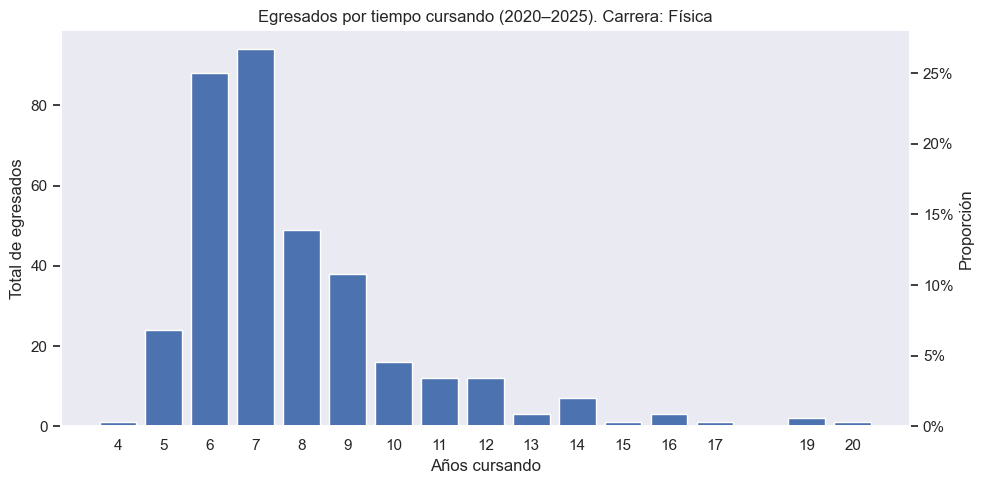

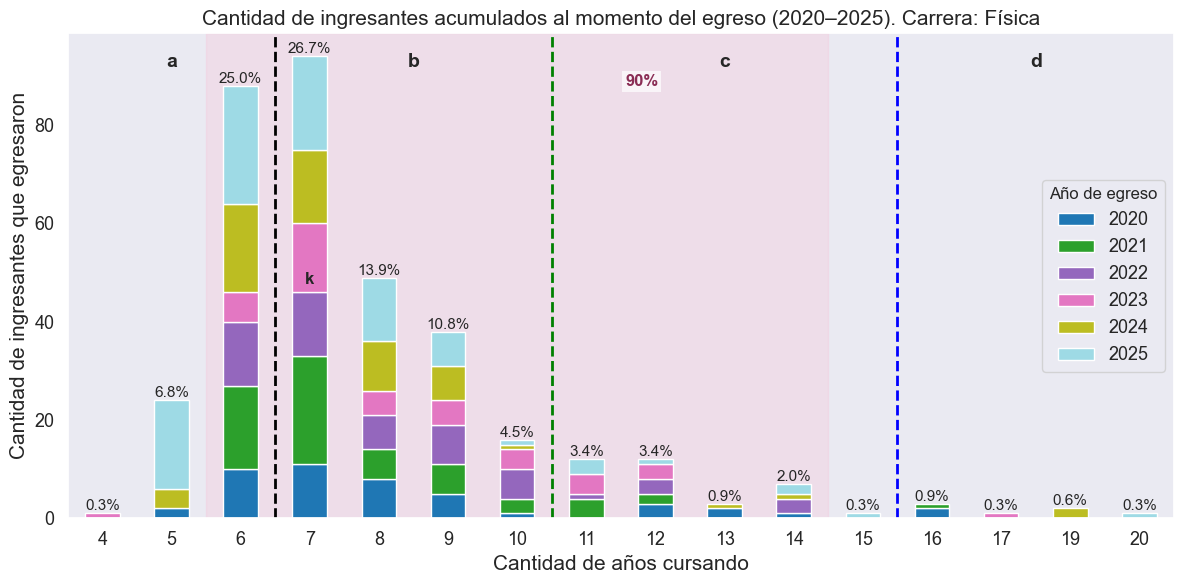

 tiempo_cursando  total_egreso
               4             1
               5            24
               6            88
               7            94
               8            49
               9            38
              10            16
              11            12
              12            12
              13             3
              14             7
              15             1
              16             3
              17             1
              19             2
              20             1
anio_egreso      2020  2021  2022  2023  2024  2025
tiempo_cursando                                    
4                   0     0     0     1     0     0
5                   2     0     0     0     4    18
6                  10    17    13     6    18    24
7                  11    22    13    14    15    19
8                   8     6     7     5    10    13
9                   5     6     8     5     7     7
10                  1     3     6     4     1     1
11   

In [3]:
total_por_tiempo_2020_2025, resumen_por_cohorte_2020_2025, promedio_ponderado = plot_tiempo_cursando(egresados_fisica_2020_2025, 'Física', anio_desde=2020, anio_hasta=2025, mostrar_rectas_verticales=True)

In [4]:
# 1. Creamos la serie expandida de años
datos_expandidos = np.repeat(total_por_tiempo_2020_2025['tiempo_cursando'], total_por_tiempo_2020_2025['total_egreso'])

# 2. Calculamos los límites del 95% (dejamos fuera 2.5% de cada lado)
limite_inferior = np.percentile(datos_expandidos, 2.5)
limite_superior = np.percentile(datos_expandidos, 97.5)

print(f"Rango recomendado para el 95%: {limite_inferior} a {limite_superior} años")

# 3. Filtramos el DataFrame original
df_filtrado = total_por_tiempo_2020_2025[
    (total_por_tiempo_2020_2025['tiempo_cursando'] >= limite_inferior) & 
    (total_por_tiempo_2020_2025['tiempo_cursando'] <= limite_superior)
]

Rango recomendado para el 95%: 5.0 a 14.0 años


In [5]:
resumen_por_cohorte_95 = resumen_por_cohorte_2020_2025[
    (resumen_por_cohorte_2020_2025.index >= limite_inferior) & 
    (resumen_por_cohorte_2020_2025.index <= limite_superior)
]

chi2, p, dof, expected = chi2_contingency(resumen_por_cohorte_95)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 88.1465803193855
p-value: 0.00012789735784133108


In [6]:
stats = {}

for col in resumen_por_cohorte_95.columns:
    datos = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[col])
    
    stats[col] = {
        "media": np.mean(datos),
        "mediana": np.median(datos),
        "std": np.std(datos)
    }

pd.DataFrame(stats).T

,media,mediana,std
2020,7.953488,7.0,2.219926
2021,7.600000,7.0,1.665333
2022,8.259259,8.0,2.187381
2023,8.268293,8.0,1.848195
2024,7.245614,7.0,1.688773
2025,7.011364,7.0,1.897931


In [7]:
from scipy.stats import nbinom

total_por_tiempo_95 = total_por_tiempo_2020_2025[
    (total_por_tiempo_2020_2025['tiempo_cursando'] >= limite_inferior) & 
    (total_por_tiempo_2020_2025['tiempo_cursando'] <= limite_superior)
]

# 1. Expandir datos para cálculos estadísticos
datos_completos = np.repeat(total_por_tiempo_95["tiempo_cursando"], total_por_tiempo_95["total_egreso"])

# 2. Desplazar datos (Restamos el mínimo o la duración nominal, ej. 5)
shift = limite_inferior
shift_entero = int(round(shift))

datos_desplazados = datos_completos - shift_entero
# Nota: Si algún dato queda negativo (como el año 3), 
# se suele truncar a 0 o elegir un shift más pequeño.
datos_desplazados = np.maximum(datos_desplazados, 0)

mu = np.mean(datos_desplazados)
var = np.var(datos_desplazados)

print(f"Media: {mu:.2f}, Varianza: {var:.2f}")

if var > mu:
    # 3. Estimar parámetros n y p para la Binomial Negativa
    print("La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!")
    p = mu / var
    n = (mu**2) / (var - mu)
    print(f"Parámetros estimados: n={n:.2f}, p={p:.2f}")
else:
    print("Incluso desplazando, la varianza es menor. Considera una Binomial común.")

Media: 2.62, Varianza: 3.91
La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!
Parámetros estimados: n=5.31, p=0.67


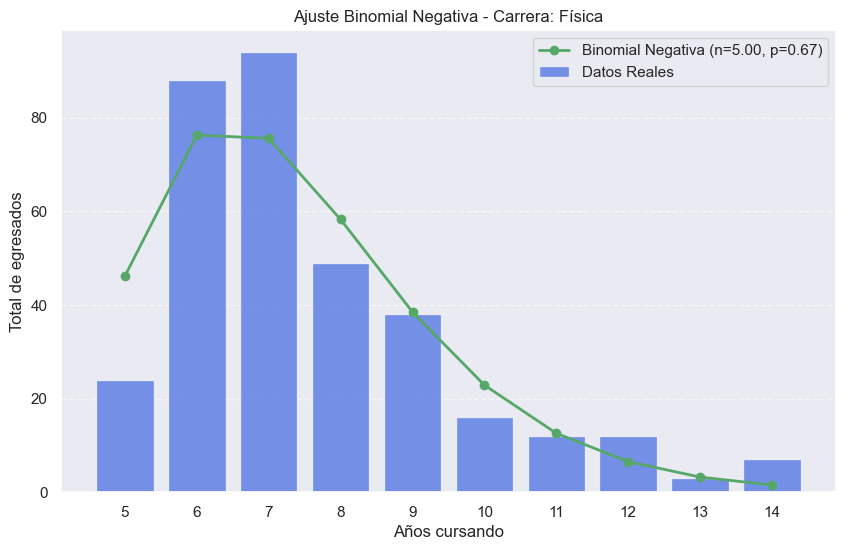

In [8]:
from scipy.stats import binom
import matplotlib.pyplot as plt
p_est = mu / var
n_est = int(round((mu**2) / (var - mu)))

# Eje X para la curva (desde el desplazamiento hacia adelante)
x_teorico = np.arange(0, total_por_tiempo_95['tiempo_cursando'].max() - shift_entero + 1)
y_teorico = nbinom.pmf(x_teorico, n_est, p_est) * total_por_tiempo_95['total_egreso'].sum()

# 4. Graficamos
plt.figure(figsize=(10, 6))

# Barras reales
plt.bar(total_por_tiempo_95['tiempo_cursando'], total_por_tiempo_95['total_egreso'], color='royalblue', alpha=0.7, label='Datos Reales')

# Curva Binomial Negativa
# Nota: sumamos shift para devolver la curva a su posición original en el eje X
plt.plot(x_teorico + shift_entero, y_teorico, 'go-', lw=2, 
            label=f'Binomial Negativa (n={n_est:.2f}, p={p_est:.2f})')

plt.title('Ajuste Binomial Negativa - Carrera: Física')
plt.xlabel('Años cursando')
plt.ylabel('Total de egresados')
plt.xticks(np.arange(int(round(limite_inferior)), int(round(limite_superior)) + 1, 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [9]:
# Cálculo del MAPE
# Nota: solo funciona si no tienes años con 0 egresados (para evitar dividir por cero)
mape = np.mean(np.abs((total_por_tiempo_95['total_egreso'].to_numpy() - y_teorico) / total_por_tiempo_95['total_egreso'].to_numpy())) * 100

print(f"El error porcentual medio (MAPE) es: {mape:.2f}%")

El error porcentual medio (MAPE) es: 32.52%


Si quiero hacerlo para la totalidad de los datos de 2014 a 2019.

In [10]:
egresados_fisica_2014_2019 = pd.DataFrame()
for anio in range(2014, 2020):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/fisica/resumen_egresados_fisica_{anio}.csv')
    egresados_fisica_2014_2019 = pd.concat([egresados_fisica_2014_2019, egresados])

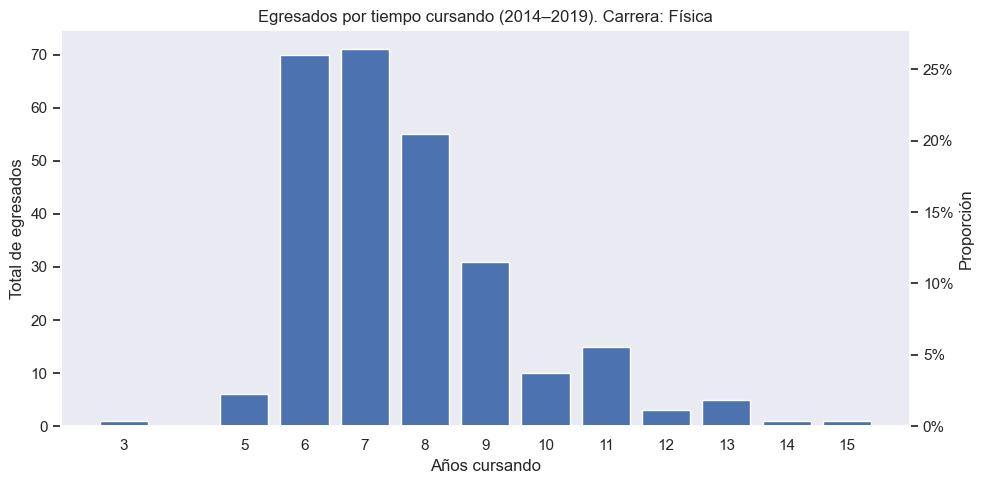

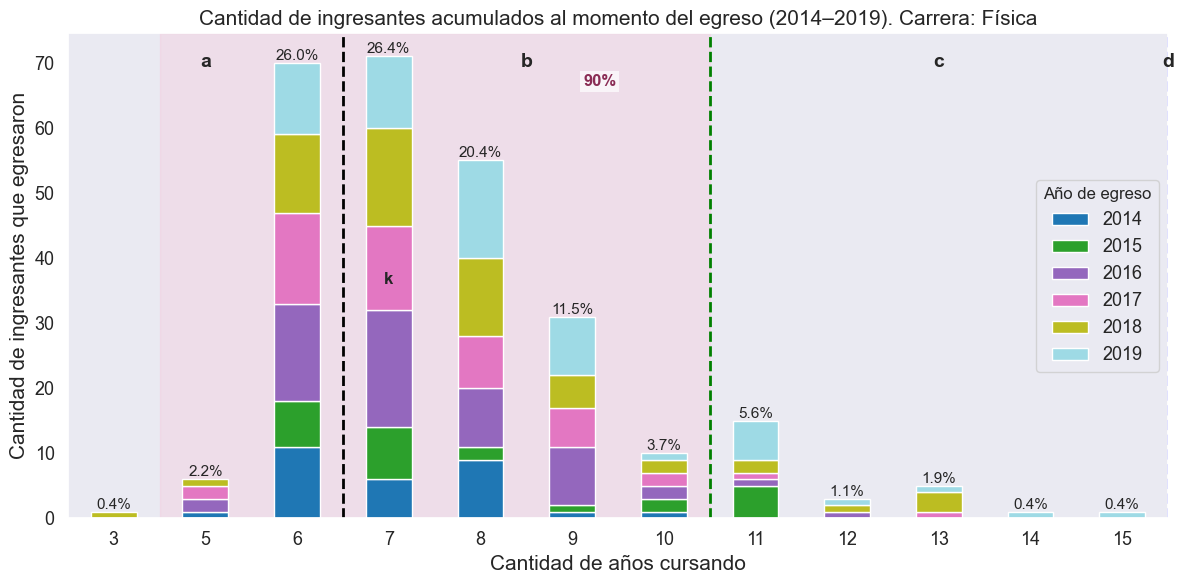

 tiempo_cursando  total_egreso
               3             1
               5             6
               6            70
               7            71
               8            55
               9            31
              10            10
              11            15
              12             3
              13             5
              14             1
              15             1
anio_egreso      2014  2015  2016  2017  2018  2019
tiempo_cursando                                    
3                   0     0     0     0     1     0
5                   1     0     2     2     1     0
6                  11     7    15    14    12    11
7                   6     8    18    13    15    11
8                   9     2     9     8    12    15
9                   1     1     9     6     5     9
10                  1     2     2     2     2     1
11                  0     5     1     1     2     6
12                  0     0     1     0     1     1
13                  0    

In [11]:
total_por_tiempo_2014_2019, resumen_por_cohorte_2014_2019, promedio_ponderado = plot_tiempo_cursando(egresados_fisica_2014_2019, 'Física', anio_desde=2014, anio_hasta=2019, mostrar_rectas_verticales=True)

In [12]:
chi2, p, dof, expected = chi2_contingency(resumen_por_cohorte_2014_2019)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 56.708704546001066
p-value: 0.4110993771346636


In [13]:
# tu tabla original
df = resumen_por_cohorte_2014_2019.copy()

# asegurarnos que el índice sea numérico
df.index = df.index.astype(int)

# función para agrupar
def agrupar_tiempo(t):
    if t <= 6:
        return "<=6"
    elif t == 7:
        return "7"
    elif t >= 8:
        return "8+"

# crear nueva categoría
df["grupo"] = df.index.map(agrupar_tiempo)

# agrupar sumando
df_grouped = df.groupby("grupo").sum().loc[["<=6", "7", "8+"]]

# correr test
chi2, p, dof, expected = chi2_contingency(df_grouped)

print(df_grouped)
print("Chi2:", chi2)
print("p-value:", p)

anio_egreso  2014  2015  2016  2017  2018  2019
grupo                                          
<=6            12     7    17    16    14    11
7               6     8    18    13    15    11
8+             11    10    22    18    25    35
Chi2: 11.30238289459028
p-value: 0.3344499765506268


In [14]:
from scipy.stats import nbinom

total_por_tiempo_mayor_5 = total_por_tiempo_2014_2019[
    (total_por_tiempo_2014_2019['tiempo_cursando'] >= 5)
]

# 1. Expandir datos para cálculos estadísticos
datos_completos = np.repeat(total_por_tiempo_mayor_5["tiempo_cursando"], total_por_tiempo_mayor_5["total_egreso"])

# 2. Desplazar datos (Restamos el mínimo o la duración nominal, ej. 5)
shift = 5
shift_entero = int(round(shift))

print(f"Desplazando datos restando {shift_entero} años...")

datos_desplazados = datos_completos - shift_entero
# Nota: Si algún dato queda negativo (como el año 3), 
# se suele truncar a 0 o elegir un shift más pequeño.
datos_desplazados = np.maximum(datos_desplazados, 0)

mu = np.mean(datos_desplazados)
var = np.var(datos_desplazados)

print(f"Media: {mu:.2f}, Varianza: {var:.2f}")

if var > mu:
    # 3. Estimar parámetros n y p para la Binomial Negativa
    print("La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!")
    p = mu / var
    n = (mu**2) / (var - mu)
    print(f"Parámetros estimados: n={n:.2f}, p={p:.2f}")
else:
    print("Incluso desplazando, la varianza es menor. Considera una Binomial común.")

Desplazando datos restando 5 años...
Media: 2.69, Varianza: 3.15
La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!
Parámetros estimados: n=15.86, p=0.85


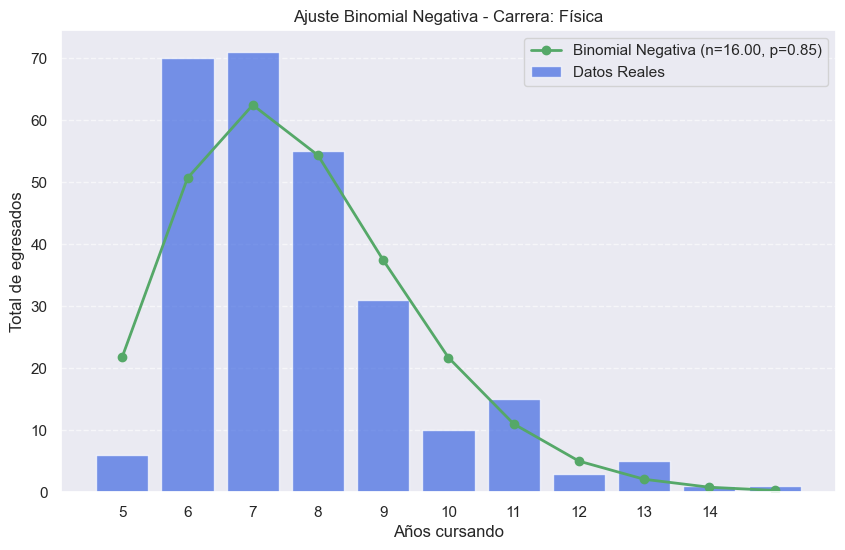

In [15]:
from scipy.stats import binom
import matplotlib.pyplot as plt
p_est = mu / var
n_est = int(round((mu**2) / (var - mu)))

# Eje X para la curva (desde el desplazamiento hacia adelante)
x_teorico = np.arange(0, total_por_tiempo_mayor_5['tiempo_cursando'].max() - shift_entero + 1)
y_teorico = nbinom.pmf(x_teorico, n_est, p_est) * total_por_tiempo_mayor_5['total_egreso'].sum()

# 4. Graficamos
plt.figure(figsize=(10, 6))

# Barras reales
plt.bar(total_por_tiempo_mayor_5['tiempo_cursando'], total_por_tiempo_mayor_5['total_egreso'], color='royalblue', alpha=0.7, label='Datos Reales')

# Curva Binomial Negativa
# Nota: sumamos shift para devolver la curva a su posición original en el eje X
plt.plot(x_teorico + shift_entero, y_teorico, 'go-', lw=2, 
            label=f'Binomial Negativa (n={n_est:.2f}, p={p_est:.2f})')

plt.title('Ajuste Binomial Negativa - Carrera: Física')
plt.xlabel('Años cursando')
plt.ylabel('Total de egresados')
plt.xticks(np.arange(int(round(limite_inferior)), int(round(limite_superior)) + 1, 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [16]:
# Cálculo del MAPE
# Nota: solo funciona si no tienes años con 0 egresados (para evitar dividir por cero)
mape = np.mean(np.abs((total_por_tiempo_mayor_5['total_egreso'].to_numpy() - y_teorico) / total_por_tiempo_mayor_5['total_egreso'].to_numpy())) * 100

print(f"El error porcentual medio (MAPE) es: {mape:.2f}%")

El error porcentual medio (MAPE) es: 62.24%


In [17]:
mse_manual = np.mean((total_por_tiempo_mayor_5['total_egreso'].to_numpy() - y_teorico)**2)

print(f"MSE: {mse_manual:.4f}")

MSE: 82.2425


In [18]:
error_total_relativo = (np.sum(np.abs(total_por_tiempo_mayor_5['total_egreso'].to_numpy()- y_teorico)) / np.sum(total_por_tiempo_mayor_5['total_egreso'].to_numpy())) * 100
print(f"Error relativo total: {error_total_relativo:.2f}%")

Error relativo total: 26.97%


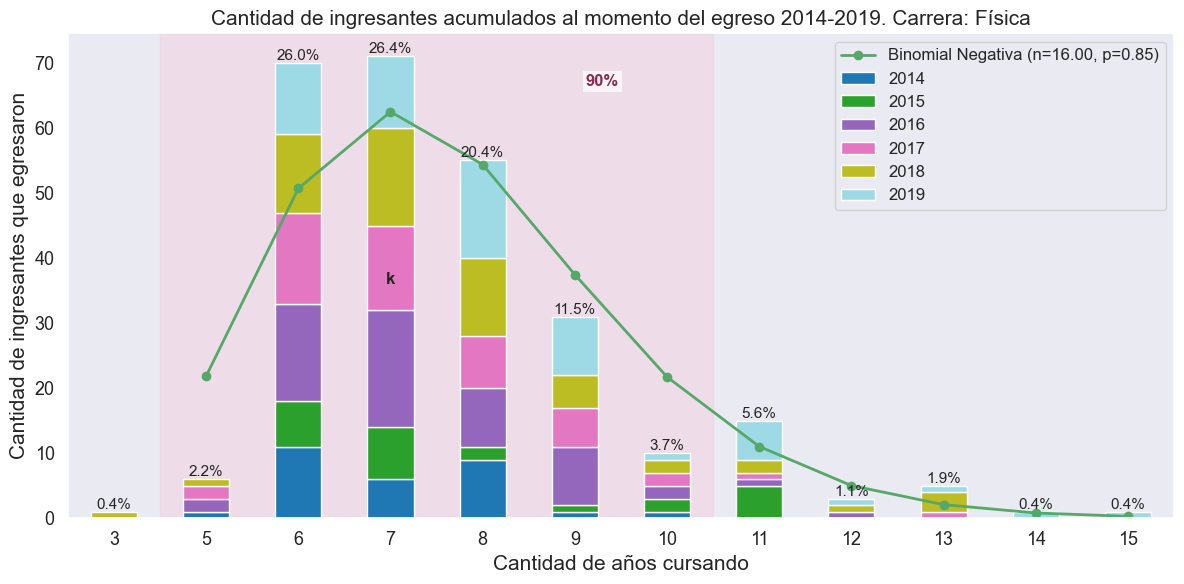

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
resumen_por_cohorte_2014_2019.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("Cantidad de años cursando", fontsize=15)
ax.set_ylabel("Cantidad de ingresantes que egresaron", fontsize=15)
ax.set_title(f"Cantidad de ingresantes acumulados al momento del egreso 2014-2019. Carrera: Física", fontsize=15)
ax.tick_params(axis="x", rotation=0, labelsize=13)
ax.tick_params(axis="y", labelsize=13)

totales_por_tiempo = resumen_por_cohorte_2014_2019.sum(axis=1)
cantidades = totales_por_tiempo.tolist()
pos_k = resumen_por_cohorte_2014_2019.index.get_loc(totales_por_tiempo.idxmax())
total = sum(cantidades)
objetivo = 0.9 * total
n_barras = len(cantidades)
k_en_borde = pos_k == 0 or pos_k == n_barras - 1
mejor_tramo = None
for izq in range(0, pos_k + 1):
    for der in range(pos_k, n_barras):
        if not k_en_borde and not (izq < pos_k and der > pos_k):
            continue
        suma_tramo = sum(cantidades[izq : der + 1])
        distancia = abs(suma_tramo - objetivo)
        usa_ambos_lados = izq < pos_k and der > pos_k
        criterio = (distancia, 0 if usa_ambos_lados else 1, der - izq)
        if mejor_tramo is None or criterio < mejor_tramo[0]:
            mejor_tramo = (criterio, izq, der)

if mejor_tramo is not None:
    _, izq_sombreado, der_sombreado = mejor_tramo
    ax.axvspan(
        izq_sombreado - 0.5,
        der_sombreado + 0.5,
        color="#f7c6d9",
        alpha=0.35,
        zorder=0,
    )
    x_centro = (izq_sombreado + der_sombreado) / 2 + 1.8
    y_texto = ax.get_ylim()[1] * 0.90
    ax.text(
        x_centro,
        y_texto,
        "90%",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#8a2d55",
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 2},
    )

valor_k = resumen_por_cohorte_2014_2019.index[pos_k]
altura_k = cantidades[pos_k]/2
ax.text(
    pos_k,
    altura_k,
    f"k",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold",
)

# Curva Binomial Negativa
# Nota: sumamos shift para devolver la curva a su posición original en el eje X
x_plot = np.arange(len(x_teorico))  # 0,1,2,... igual que las barras

plt.plot(x_plot + 1, y_teorico, 'go-', lw=2, 
            label=f'Binomial Negativa (n={n_est:.2f}, p={p_est:.2f})')

grand_total = total_por_tiempo_2014_2019["total_egreso"].sum()
for i, tc in enumerate(resumen_por_cohorte_2014_2019.index):
    total_height = resumen_por_cohorte_2014_2019.loc[tc].sum()
    proporcion_simple = (total_height / grand_total) if grand_total else 0
    ax.text(i, total_height, f"{proporcion_simple:.1%}", ha="center", va="bottom", fontsize=11)

ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Computación

In [20]:
egresados_computacion_2020_2025 = pd.DataFrame()
for anio in range(2020, 2026):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/computacion/resumen_egresados_computacion_{anio}.csv')
    egresados_computacion_2020_2025 = pd.concat([egresados_computacion_2020_2025, egresados])

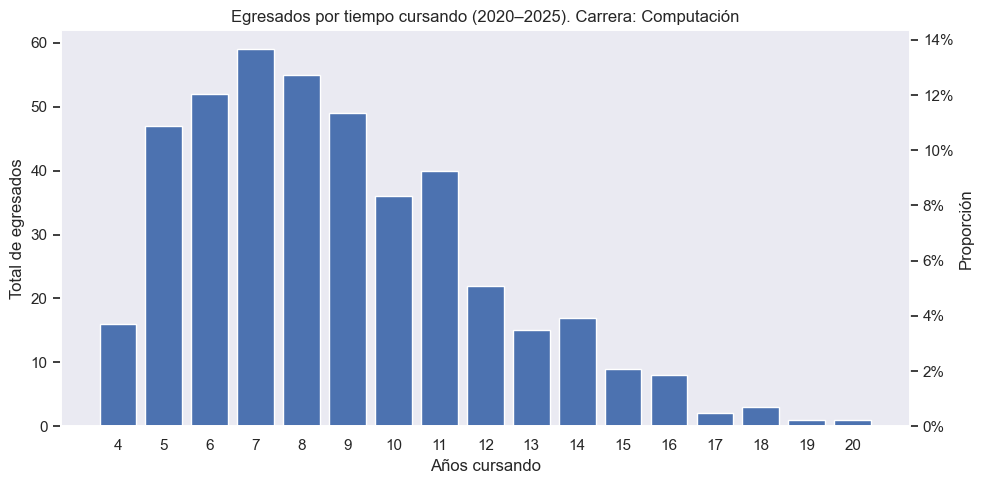

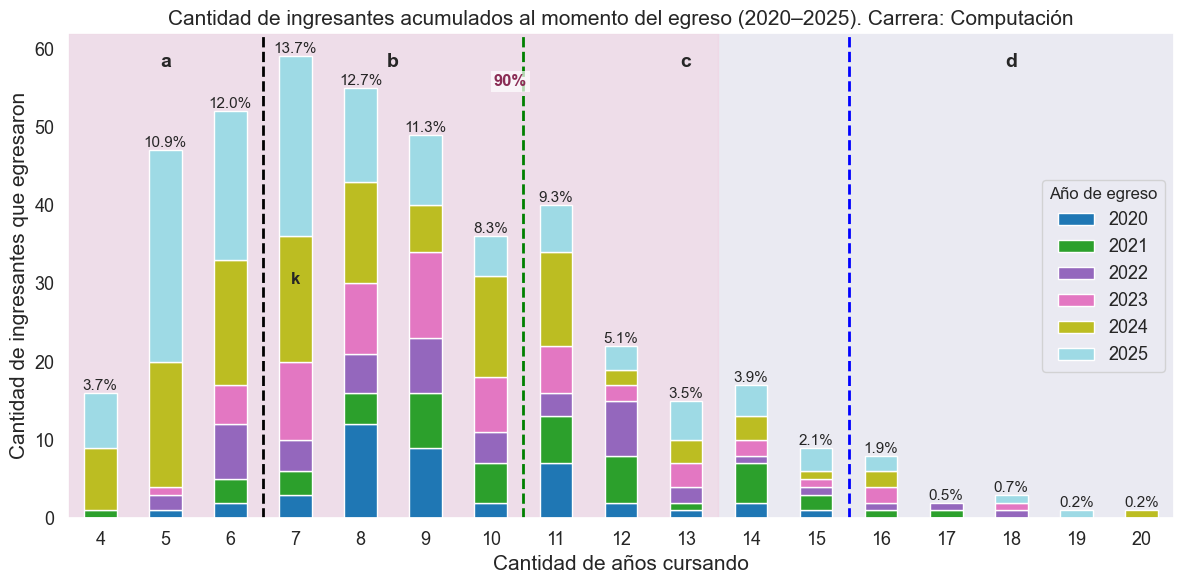

 tiempo_cursando  total_egreso
               4            16
               5            47
               6            52
               7            59
               8            55
               9            49
              10            36
              11            40
              12            22
              13            15
              14            17
              15             9
              16             8
              17             2
              18             3
              19             1
              20             1
anio_egreso      2020  2021  2022  2023  2024  2025
tiempo_cursando                                    
4                   0     1     0     0     8     7
5                   1     0     2     1    16    27
6                   2     3     7     5    16    19
7                   3     3     4    10    16    23
8                  12     4     5     9    13    12
9                   9     7     7    11     6     9
10                  2     

In [21]:
total_por_tiempo_2020_2025_computacion, resumen_por_cohorte_2020_2025_computacion, promedio_ponderado_computacion = plot_tiempo_cursando(egresados_computacion_2020_2025, 'Computación', anio_desde=2020, anio_hasta=2025, mostrar_rectas_verticales=True)

In [22]:
import numpy as np
# 1. Creamos la serie expandida de años
datos_expandidos_compu = np.repeat(total_por_tiempo_2020_2025_computacion['tiempo_cursando'], total_por_tiempo_2020_2025_computacion['total_egreso'])

# 2. Calculamos los límites del 95% (dejamos fuera 2.5% de cada lado)
limite_inferior_compu = np.percentile(datos_expandidos_compu, 2.5)
limite_superior_compu = np.percentile(datos_expandidos_compu, 97.5)

print(f"Rango recomendado para el 95%: {limite_inferior_compu} a {limite_superior_compu} años")

# 3. Filtramos el DataFrame original
df_filtrado_compu = total_por_tiempo_2020_2025_computacion[
    (total_por_tiempo_2020_2025_computacion['tiempo_cursando'] >= limite_inferior_compu) & 
    (total_por_tiempo_2020_2025_computacion['tiempo_cursando'] <= limite_superior_compu)
]

Rango recomendado para el 95%: 4.0 a 16.0 años


In [23]:
from scipy.stats import chi2_contingency

resumen_por_cohorte_95_compu = resumen_por_cohorte_2020_2025_computacion[
    (resumen_por_cohorte_2020_2025_computacion.index >= limite_inferior_compu) & 
    (resumen_por_cohorte_2020_2025_computacion.index <= limite_superior_compu)
]

chi2, p, dof, expected = chi2_contingency(resumen_por_cohorte_95_compu)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 118.17460074211148
p-value: 1.1126113649849304e-05


## Biologia

In [24]:
egresados_biologia_2020_2025 = pd.DataFrame()
for anio in range(2020, 2026):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/biologia/resumen_egresados_biologia_{anio}.csv')
    egresados_biologia_2020_2025 = pd.concat([egresados_biologia_2020_2025, egresados])

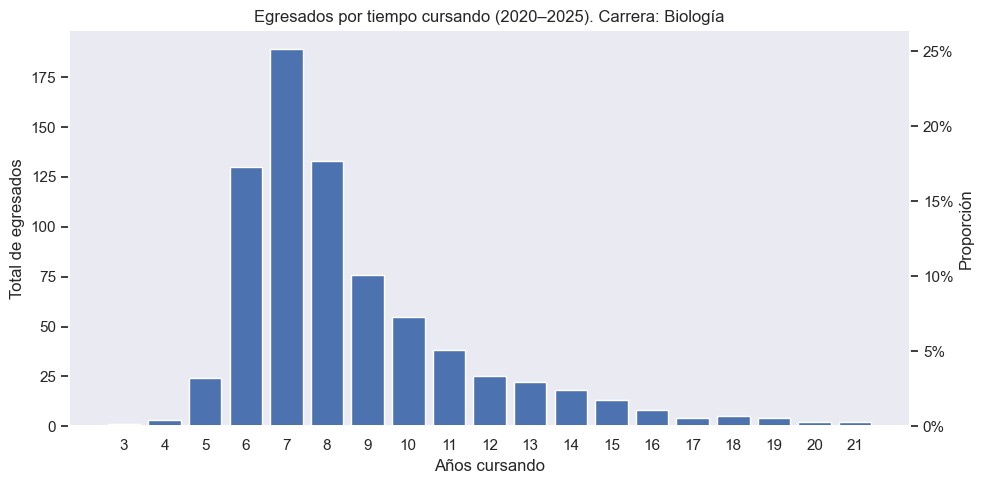

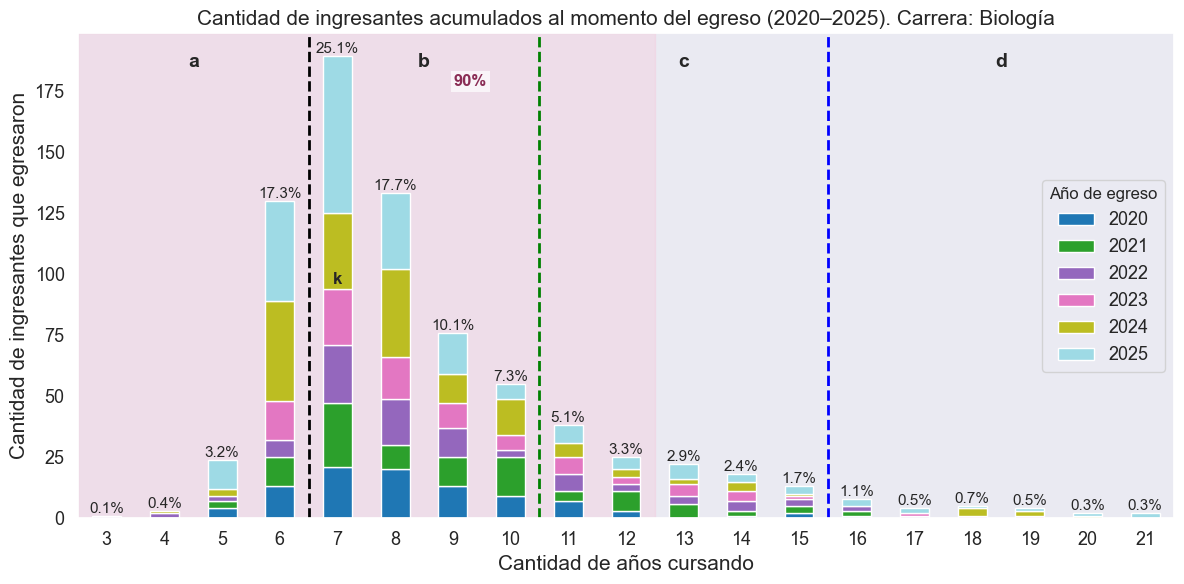

 tiempo_cursando  total_egreso
               3             1
               4             3
               5            24
               6           130
               7           189
               8           133
               9            76
              10            55
              11            38
              12            25
              13            22
              14            18
              15            13
              16             8
              17             4
              18             5
              19             4
              20             2
              21             2
anio_egreso      2020  2021  2022  2023  2024  2025
tiempo_cursando                                    
3                   0     0     1     0     0     0
4                   0     0     2     0     1     0
5                   4     3     2     0     3    12
6                  13    12     7    16    41    41
7                  21    26    24    23    31    64
8               

In [25]:
total_por_tiempo_2020_2025_biologia, resumen_por_cohorte_2020_2025_biologia, promedio_ponderado_biologia = plot_tiempo_cursando(egresados_biologia_2020_2025, 'Biología', anio_desde=2020, anio_hasta=2025, mostrar_rectas_verticales=True)

In [26]:
# 1. Creamos la serie expandida de años
datos_expandidos_bio = np.repeat(total_por_tiempo_2020_2025_biologia['tiempo_cursando'], total_por_tiempo_2020_2025_biologia['total_egreso'])

# 2. Calculamos los límites del 95% (dejamos fuera 2.5% de cada lado)
limite_inferior_bio = np.percentile(datos_expandidos_bio, 2.5)
limite_superior_bio = np.percentile(datos_expandidos_bio, 97.5)

print(f"Rango recomendado para el 95%: {limite_inferior_bio} a {limite_superior_bio} años")

# 3. Filtramos el DataFrame original
df_filtrado_bio = total_por_tiempo_2020_2025_biologia[
    (total_por_tiempo_2020_2025_biologia['tiempo_cursando'] >= limite_inferior_bio) & 
    (total_por_tiempo_2020_2025_biologia['tiempo_cursando'] <= limite_superior_bio)
]

Rango recomendado para el 95%: 5.0 a 16.0 años


In [27]:
from scipy.stats import chi2_contingency

resumen_por_cohorte_95_bio = resumen_por_cohorte_2020_2025_biologia[
    (resumen_por_cohorte_2020_2025_biologia.index >= limite_inferior_bio) & 
    (resumen_por_cohorte_2020_2025_biologia.index <= limite_superior_bio)
]

chi2, p, dof, expected = chi2_contingency(resumen_por_cohorte_95_bio)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 93.4878078546472
p-value: 0.0009296249023718674
